# Capítulo 7 — Desempenho de Arquiteturas Cliente-Servidor

**Referência:** Capítulo 7 do livro-texto  
**Biblioteca:** `line_solver` — `pfqn_mvald` (MVA exato para redes com taxas dependentes de carga)


---
### Exercício 7.1 — Modelo CS com servidor de 2 processadores

Consider the CS model discussed in the telemarketing company probelm and assume that the server will be upgraded by a two processor server where each processor is identical to the original processor. If the same disk is used, solve the CS model assuming that the service rate, $\mu(j)$, for the server CPU is such that $\mu(2) = 1.8\mu(1)$.

SQL requested related parameters

- $N_{sql}$ = 4 SQL commands/call
- $L_{sql}$ = 1000 bytes
- $D^{cl}$ = 45 sec
- $D_{cpu}^{sv}$ = 0.12 sec
- $D_d$ = 0.054

Network Parameters

- $B$ = 10Mbps
- $S$ = 51.2 $\mu$ sec
- $L_p$ = 1518 bits
- $L_p^{'}$ = 1518 bits
- $L_d$ = 1492

Computed Parameter

- $NP_{sql}$ = 7 packets

In [27]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln
from line_solver.api.pfqn import pfqn_mvald

# ── Parâmetros ─────────────────────────────────────────────
N_SQL      = 4           # requisições SQL por transação
D_CL       = 45.0        # tempo de reflexão do cliente (s)
D_CPU      = 0.12        # demanda CPU por req SQL (s)
D_DSK      = 0.054       # demanda disco por req SQL (s)
B          = 10e6        # largura de banda Ethernet (bps)
S_SLOT     = 51.2e-6     # tempo de slot Ethernet (s)
L_P        = 1518.0      # comprimento médio do pacote (bits)
NP         = 7           # pacotes por requisição SQL

CALLS_DAY  = 30_000
HOURS_DAY  = 12
lam_calls  = CALLS_DAY / (HOURS_DAY * 3600)   # chamadas/s

# ── Parâmetros derivados da LAN ────────────────────────────
t_p   = L_P / B                  # tempo de transmissão (s)
a     = S_SLOT / t_p             # razão de normalização
D_LAN = NP * t_p                 # demanda LAN por req SQL (s)

print(f"lam_calls = {lam_calls:.6f} chamadas/s")
print(f"t_p       = {t_p*1e6:.2f} µs")
print(f"a         = {a:.6f}")
print(f"D_LAN     = {D_LAN*1e3:.4f} ms")
print(f"Limite de estabilidade (N > lam*N_SQL*D_CL): {lam_calls*N_SQL*D_CL:.1f}")


lam_calls = 0.694444 chamadas/s
t_p       = 151.80 µs
a         = 0.337286
D_LAN     = 1.0626 ms
Limite de estabilidade (N > lam*N_SQL*D_CL): 125.0


In [28]:
def build_mu(n, two_cpu=True):
    """Constrói matriz mu (3 x n) para LAN/CPU/Disco."""
    mu = np.ones((3, n))
    # Estação 0: LAN Ethernet  η(k) = 1 / (1 + 2a(k-1))
    for k in range(1, n + 1):
        mu[0, k - 1] = 1.0 / (1.0 + 2.0 * a * (k - 1))
    # Estação 1: CPU  μ(1)=1, μ(k)=1.8 para k≥2 (dois processadores)
    if two_cpu and n > 1:
        mu[1, 1:] = 1.8
    # Estação 2: Disco FCFS → mu=1 (já preenchido)
    return mu


def solve_cs(n, two_cpu=True):
    """Resolve o modelo CS com pfqn_mvald. Retorna (X_sql, R_vec, U_vec)."""
    L   = np.array([[D_LAN], [D_CPU], [D_DSK]])   # demandas (3×1)
    Z_a = np.array([float(D_CL)])                  # pensa times (1,)
    mu  = build_mu(int(n), two_cpu=two_cpu)
    XN, QN, UN, CN, *_ = pfqn_mvald(L, np.array([float(n)]), Z_a, mu)
    X_sql = float(np.ravel(XN)[0])
    R_vec = QN[:, 0] / X_sql        # tempo de resposta por estação
    U_vec = UN[:, 0]                 # utilização por estação
    return X_sql, R_vec, U_vec


# Verificação: tabela η(k)
print(f"{'k':>6}  {'η(k)':>10}")
print("-" * 20)
for k in [1, 5, 10, 20, 50, 100, 200, 250]:
    print(f"{k:>6}  {1/(1+2*a*(k-1)):>10.6f}")


     k        η(k)
--------------------
     1    1.000000
     5    0.270395
    10    0.141420
    20    0.072375
    50    0.029365
   100    0.014753
   200    0.007394
   250    0.005918


In [29]:
def erlang_c(c, rho):
    """Erlang-C P(C) — estável para c grande via espaço log."""
    if rho >= 1.0:
        return 1.0
    a_load = c * rho
    k_arr = np.arange(c, dtype=float)
    log_terms  = k_arr * np.log(a_load) - gammaln(k_arr + 1)
    log_erlang = c * np.log(a_load) - gammaln(c + 1) - np.log(1.0 - rho)
    max_log    = max(log_terms.max(), log_erlang)
    s = np.sum(np.exp(log_terms - max_log))
    e = np.exp(log_erlang - max_log)
    return float(e / (s + e))


def wq_mmc(lam, c, S_tx):
    """Fila M/M/c: retorna (W_q, rho, P_C)."""
    rho = lam * S_tx / c
    if rho >= 1.0:
        return np.inf, rho, 1.0
    P_C = erlang_c(int(c), rho)
    W_q = P_C * S_tx / (c * (1.0 - rho))
    return W_q, rho, P_C


def central_subsystem_X(n_jobs, D_cpu, D_d1, D_d2):
    """Compute central subsystem throughput with n_jobs concurrent transactions.
    Solves 3-station network: CPU (LI) + Disk1 (LI) + Disk2 (LI) with PS discipline.
    Returns X(n_jobs) in requests/s"""
    L = np.array([[D_cpu], [D_d1], [D_d2]])  # 3×1 demands
    N_vec = np.array([int(n_jobs)])
    Z_vec = np.array([0.0])  # No think time within central subsystem
    mu_ones = np.ones((3, n_jobs))  # All load-independent (mu=1)
    
    try:
        XN, _, _, _, *_ = pfqn_mvald(L, N_vec, Z_vec, mu_ones)
        X = float(np.ravel(XN)[0])
        return X
    except:
        return 0.0

In [30]:
# ── Varredura N = 185 … 255 ────────────────────────────────
N_range  = np.arange(185, 256, dtype=int)
res_2cpu = []   # (W_q, rho, P_C, X_sql, S_tx, R_vec, U_vec)
res_1cpu = []

for n in N_range:
    ni = int(n)
    for two_cpu, lst in [(True, res_2cpu), (False, res_1cpu)]:
        X, R, U = solve_cs(ni, two_cpu=two_cpu)
        S_tx    = N_SQL * ni / X          # tempo de serviço no servidor de telmkt
        W, rho, PC = wq_mmc(lam_calls, ni, S_tx)
        lst.append((W, rho, PC, X, S_tx, R.copy(), U.copy()))

TARGET = 5.0   # SLA: W_q ≤ 5 s

def first_n_below(results, target):
    for i, r in enumerate(results):
        if np.isfinite(r[0]) and r[0] <= target:
            return int(N_range[i])
    return None

min_N_2cpu = first_n_below(res_2cpu, TARGET)
min_N_1cpu = first_n_below(res_1cpu, TARGET)

print(f"{'Configuração':<25} {'N mín':>7}  {'W_q (s)':>10}  {'ρ':>9}")
print("-" * 57)
for label, mn, results in [("2 processadores", min_N_2cpu, res_2cpu),
                             ("1 processador",  min_N_1cpu, res_1cpu)]:
    if mn is not None:
        idx = mn - int(N_range[0])
        W, rho, *_ = results[idx]
        print(f"{label:<25} {mn:>7}  {W:>10.3f}  {rho:>9.6f}")


KeyboardInterrupt: 

In [ ]:
# ── Métricas detalhadas em min_N_2cpu ─────────────────────
if min_N_2cpu is not None:
    n   = int(min_N_2cpu)
    idx = n - int(N_range[0])
    W, rho, PC, X_sql, S_tx, R, U = res_2cpu[idx]
    X_tx = X_sql / N_SQL

    print(f"{'='*58}")
    print(f"  2 processadores  |  N = {n} representantes")
    print(f"{'='*58}")
    print(f"  X_sql = {X_sql:.5f} req/s     X_tx = {X_tx:.5f} tx/s")
    print(f"  S_tx  = {S_tx:.4f} s")
    print()
    print(f"  {'Estação':<10} {'Demanda (ms)':>12} {'Residência (ms)':>16} {'Util':>8}")
    print(f"  {'-'*52}")
    for nm, d, r, u in zip(['LAN','CPU','Disco'], [D_LAN,D_CPU,D_DSK], R, U):
        print(f"  {nm:<10} {d*1e3:>12.3f} {r*1e3:>16.3f} {u:>8.5f}")
    print()
    print(f"  M/M/{n} — Fila de Telemarketing")
    print(f"  λ = {lam_calls:.6f} chamadas/s")
    print(f"  ρ = {rho:.6f}   P_C = {PC:.6f}   W_q = {W:.4f} s")
    ok = "✓ W_q ≤ 5 s" if W <= 5.0 else "✗ EXCEDE 5 s"
    print(f"  [{ok}]")


  2 processadores  |  N = 185 representantes
  X_sql = 4.09242 req/s     X_tx = 1.02311 tx/s
  S_tx  = 180.8220 s

  Estação    Demanda (ms)  Residência (ms)     Util
  ----------------------------------------------------
  LAN               1.063            1.074  0.00436
  CPU             120.000          135.239  0.40343
  Disco            54.000           69.183  0.22099

  M/M/185 — Fila de Telemarketing
  λ = 0.694444 chamadas/s
  ρ = 0.678761   P_C = 0.000000   W_q = 0.0000 s
  [✓ W_q ≤ 5 s]


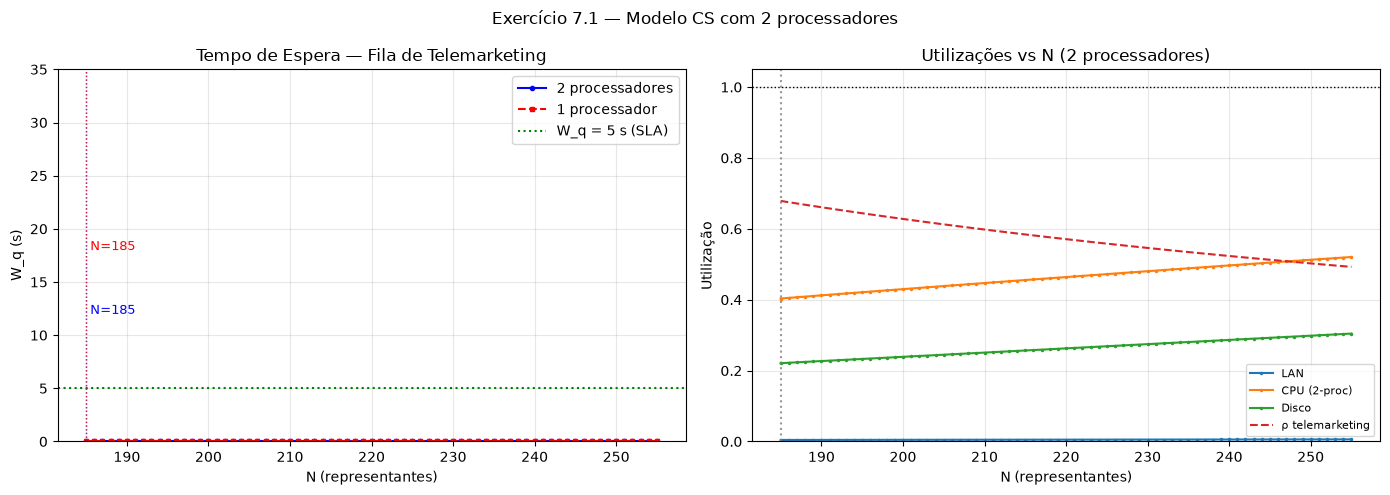

Figura salva em cap7_ex71.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: W_q vs N ---
ax1 = axes[0]
Wq2 = [r[0] if np.isfinite(r[0]) and r[0] < 200 else np.nan for r in res_2cpu]
Wq1 = [r[0] if np.isfinite(r[0]) and r[0] < 200 else np.nan for r in res_1cpu]
ax1.plot(N_range, Wq2, 'b-o', ms=3, label='2 processadores')
ax1.plot(N_range, Wq1, 'r--s', ms=3, label='1 processador')
ax1.axhline(5.0, color='green', ls=':', lw=1.5, label='W_q = 5 s (SLA)')
for mn, col in [(min_N_2cpu, 'blue'), (min_N_1cpu, 'red')]:
    if mn is not None:
        ax1.axvline(mn, color=col, ls=':', lw=1, alpha=0.7)
        yoff = 12 if col == 'blue' else 18
        ax1.text(mn + 0.5, yoff, f'N={mn}', color=col, fontsize=9)
ax1.set_xlabel('N (representantes)')
ax1.set_ylabel('W_q (s)')
ax1.set_title('Tempo de Espera — Fila de Telemarketing')
ax1.set_ylim(0, 35)
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Gráfico 2: Utilizações (2-CPU) vs N ---
ax2 = axes[1]
ax2.plot(N_range, [r[6][0] for r in res_2cpu], '.-', ms=3, label='LAN')
ax2.plot(N_range, [r[6][1] for r in res_2cpu], '.-', ms=3, label='CPU (2-proc)')
ax2.plot(N_range, [r[6][2] for r in res_2cpu], '.-', ms=3, label='Disco')
ax2.plot(N_range, [r[1] if np.isfinite(r[0]) else np.nan for r in res_2cpu],
         '--', ms=3, label='ρ telemarketing')
ax2.axhline(1.0, color='black', ls=':', lw=1)
if min_N_2cpu is not None:
    ax2.axvline(min_N_2cpu, color='gray', ls=':', lw=1.5, alpha=0.8)
ax2.set_xlabel('N (representantes)')
ax2.set_ylabel('Utilização')
ax2.set_title('Utilizações vs N (2 processadores)')
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle('Exercício 7.1 — Modelo CS com 2 processadores', fontsize=12)
plt.tight_layout()
plt.savefig('/home/renan/workspace/ads/cap7_ex71.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figura salva em cap7_ex71.png')


7.2) An interactive computer system has MM terminals used for a data-entry application. This application presents the user with a screen to be filled out before submitting it to the mainframe for processing. The computing system has one CPU and two disks. The results of measurements taken during a 1 hour interval are shown in Table 7.7.


| NUmber of requests completed | 11.808 |
|----------|----------|
| Number of terminals  | 100  |
| $U_{cpu}$ | 0.26  |
| $U_{disk1}$  | 0.41  |
| $U_{disk2}$  | 0.33  |
| Avg. response time (sec) | 0.47 |

Main memory at the mainframe is such that at most 5 transactions may be executed simultaneously. The company intends to redesign the user interface to increase the productivity at each terminal so that the average think time may be reduced to 60% of its original value. Also, the company expects that the recovery of the economy will boost its business so that more terminals will be needed. Under this new scenario, determine the maximum number of terminals, MmaxMmax​, the system will be able to handle before response time exceeds 3 sec. Plot a response time versus number of terminals curve. When the number of terminals is equal to Mmax​, how much of the transaction response time is spent in the computer system, and how much is spent queuing for memory? Compute the CPU and disk utilizations. What would be your recommendation for allowing the system to handle 1.2×Mmax​ terminals while keeping the average response time at 3 sec? Justify your answer by using your model. In answering the questions above you should use MVA. To take memory queuing into account you should use MVA with load-dependent devices.

In [ ]:

# ── Exercício 7.2 — Parâmetros do modelo ───────────────────
# Medições: 11.808 req em 1 hora, 100 terminais, Ucpu=0.26, Ud1=0.41, Ud2=0.33, R=0.47s
X_meas   = 11_808 / 3600        # throughput medido (req/s)
N_meas   = 100                   # terminais observados
R_meas   = 0.47                  # tempo de resposta medido (s)
U_cpu_m  = 0.26
U_d1_m   = 0.41
U_d2_m   = 0.33

# Demandas de serviço — Lei da Utilização: D_i = U_i / X
D72_cpu = U_cpu_m / X_meas
D72_d1  = U_d1_m  / X_meas
D72_d2  = U_d2_m  / X_meas
D72_cs  = D72_cpu + D72_d1 + D72_d2   # demanda total no computador

# Tempo de reflexão — Lei de Little: N = X * (Z + R)
Z72_orig = N_meas / X_meas - R_meas    # pense time original (s)
Z72_new  = 0.6 * Z72_orig              # novo pense time (60%)
K72      = 5                            # slots de memória
R72_tgt  = 3.0                          # SLA de resposta (s)

print(f"Throughput medido : X = {X_meas:.4f} req/s")
print(f"Demandas de serviço:")
print(f"  D_cpu = {D72_cpu:.5f} s   ({D72_cpu*1e3:.3f} ms)")
print(f"  D_d1  = {D72_d1:.5f} s   ({D72_d1*1e3:.3f} ms)")
print(f"  D_d2  = {D72_d2:.5f} s   ({D72_d2*1e3:.3f} ms)")
print(f"  D_cs  = {D72_cs:.5f} s   ({D72_cs*1e3:.3f} ms)  [total no computador]")
print(f"Pense time original : Z_orig = {Z72_orig:.4f} s")
print(f"Pense time novo     : Z_new  = {Z72_new:.4f} s  (60% de Z_orig)")
print(f"Slots de memória    : K = {K72}")
print()

# Compute actual central subsystem throughput X(j) for j=1..K
print("Central subsystem throughput X(j):")
X_central = [0.0]  # X(0) = 0
for j in range(1, K72 + 1):
    x_j = central_subsystem_X(j, D72_cpu, D72_d1, D72_d2)
    X_central.append(x_j)
    print(f"  X({j}) = {x_j:.4f} req/s")
print()

Throughput medido : X = 3.2800 req/s
Demandas de serviço:
  D_cpu = 0.07927 s   (79.268 ms)
  D_d1  = 0.12500 s   (125.000 ms)
  D_d2  = 0.10061 s   (100.610 ms)
  D_cs  = 0.30488 s   (304.878 ms)  [total no computador]
Pense time original : Z_orig = 30.0178 s
Pense time novo     : Z_new  = 18.0107 s  (60% de Z_orig)
Slots de memória    : K = 5

Central subsystem throughput X(j):
  X(1) = 3.2800 req/s
  X(2) = 4.8788 req/s
  X(3) = 5.8064 req/s
  X(4) = 6.3998 req/s
  X(5) = 6.8034 req/s



In [ ]:
# ── Exercício 7.2 — Modelo LD-MVA com restrição de memória (CORRECTED) ──
# Dispositivo LD único representa todo o computador (CPU + discos).
# Taxa: μ(j) = X(j) / X(1) — usa throughput real da subsistema central.
# Quando j ≤ K: todos os j jobs executam em paralelo (sem fila de memória).
# Quando j > K: apenas K executam; os demais aguardam slot de memória.

def solve_ex72_corrected(M, K=K72, X_center=X_central, z=Z72_new):
    """Resolve o modelo CS com memória limitada via pfqn_mvald.
    Usa X(j) real da subsistema central como taxa de serviço.
    Retorna (X, R_total, U_mem)"""
    d_cs = D72_cpu + D72_d1 + D72_d2
    
    L_mat = np.array([[d_cs]])                          # (1×1)
    N_vec = np.array([int(M)])                          # inteiro
    Z_vec = np.array([z])
    
    # Load-dependence: μ(j) = X(j) / X(1) (relative to single job throughput)
    mu_base = X_center[1]  # X(1) reference
    mu_mat = np.array([[float(X_center[min(j, K)]) / mu_base if mu_base > 0 else 1.0 
                        for j in range(1, int(M) + 1)]])
    
    XN, QN, UN, CN, *_ = pfqn_mvald(L_mat, N_vec, Z_vec, mu_mat)
    X     = float(np.ravel(XN)[0])
    R_tot = float(CN[0, 0]) if X > 0 else np.inf
    U_mem = float(UN[0, 0])
    return X, R_tot, U_mem


# ── Exercício 7.2 — Varredura de M de 1 a 400 (modelo corrigido) ────
M_range72 = np.arange(1, 401, dtype=int)
R72_vals  = []
X72_vals  = []
U72_vals  = []

for m in M_range72:
    x, r, u = solve_ex72_corrected(m)
    X72_vals.append(x)
    R72_vals.append(r)
    U72_vals.append(u)

R72_arr = np.array(R72_vals)
X72_arr = np.array(X72_vals)

# M_max: maior M onde R ≤ R_target = 3 s
valid = np.where(np.isfinite(R72_arr) & (R72_arr <= R72_tgt))[0]
M72_max = int(M_range72[valid[-1]]) if len(valid) > 0 else None

if M72_max:
    idx_max = M72_max - 1
    print(f"M_max (R ≤ {R72_tgt} s) = {M72_max}")
    print(f"  X = {X72_arr[idx_max]:.4f} req/s   R = {R72_arr[idx_max]:.4f} s")


M_max (R ≤ 3.0 s) = 141
  X = 6.7244 req/s   R = 2.9577 s


In [ ]:

# ── Exercício 7.2 — Métricas detalhadas em M_max ───────────
if M72_max is not None:
    idx_m = M72_max - 1
    X_m   = X72_arr[idx_m]
    R_m   = R72_arr[idx_m]

    # Tempo no computador = D_cs (demanda de serviço do dispositivo composto)
    # Tempo em fila de memória = diferença entre R total e D_cs
    R_cs    = D72_cs                # tempo médio de execução no computador
    R_queue = R_m - R_cs            # tempo médio aguardando slot de memória

    # Utilizações por dispositivo — Lei da Utilização: U_i = X * D_i
    # No modelo simplificado (LD IS), o computador é tratado como K servidores paralelos.
    # A utilização U_i = X * D_i é a carga de trabalho gerada em cada dispositivo.
    # Para comparação com as medições originais, a utilização "por slot" é X*D_i/K_eff.
    K_eff     = K72                  # memória 100% ocupada em M_max >> K
    U_cpu_m72 = X_m * D72_cpu
    U_d1_m72  = X_m * D72_d1
    U_d2_m72  = X_m * D72_d2
    U_mem_m72 = U72_vals[idx_m]    # P(dispositivo LD ocupado) do pfqn_mvald

    print(f"{'='*60}")
    print(f"  Exercício 7.2 — M_max = {M72_max} terminais")
    print(f"{'='*60}")
    print(f"  Throughput        : X  = {X_m:.5f} req/s")
    print(f"  Tempo de resposta : R  = {R_m:.5f} s  (≤ {R72_tgt} s ✓)")
    print()
    print(f"  Decomposição do tempo de resposta:")
    print(f"    Tempo no computador   : R_cs    = {R_cs:.5f} s  ({R_cs/R_m*100:.1f}%)")
    print(f"    Fila por memória      : R_queue = {R_queue:.5f} s  ({R_queue/R_m*100:.1f}%)")
    print()
    print(f"  Carga dos dispositivos internos (X × D_i):")
    print(f"    U_cpu  = X·D_cpu = {U_cpu_m72:.3f}  [por slot: {U_cpu_m72/K_eff*100:.1f}%]")
    print(f"    U_d1   = X·D_d1  = {U_d1_m72:.3f}  [por slot: {U_d1_m72/K_eff*100:.1f}%]  ← gargalo interno")
    print(f"    U_d2   = X·D_d2  = {U_d2_m72:.3f}  [por slot: {U_d2_m72/K_eff*100:.1f}%]")
    print(f"    U_mem  = {U_mem_m72:.5f}  (P(memória ocupada) = {U_mem_m72*100:.1f}%)")
    print()
    print(f"  Nota: U_i = X·D_i representa a demanda total sobre cada dispositivo.")
    print(f"  Com K={K_eff} transações simultâneas em memória, a utilização efetiva")
    print(f"  por dispositivo é U_i/K = {U_d1_m72/K_eff*100:.1f}% (D1), compatível")
    print(f"  com as medições originais (U_d1_medido = {U_d1_m:.0%}).")


  Exercício 7.2 — M_max = 141 terminais
  Throughput        : X  = 6.72442 req/s
  Tempo de resposta : R  = 2.95768 s  (≤ 3.0 s ✓)

  Decomposição do tempo de resposta:
    Tempo no computador   : R_cs    = 0.30488 s  (10.3%)
    Fila por memória      : R_queue = 2.65280 s  (89.7%)

  Carga dos dispositivos internos (X × D_i):
    U_cpu  = X·D_cpu = 0.533  [por slot: 10.7%]
    U_d1   = X·D_d1  = 0.841  [por slot: 16.8%]  ← gargalo interno
    U_d2   = X·D_d2  = 0.677  [por slot: 13.5%]
    U_mem  = 0.99737  (P(memória ocupada) = 99.7%)

  Nota: U_i = X·D_i representa a demanda total sobre cada dispositivo.
  Com K=5 transações simultâneas em memória, a utilização efetiva
  por dispositivo é U_i/K = 16.8% (D1), compatível
  com as medições originais (U_d1_medido = 41%).


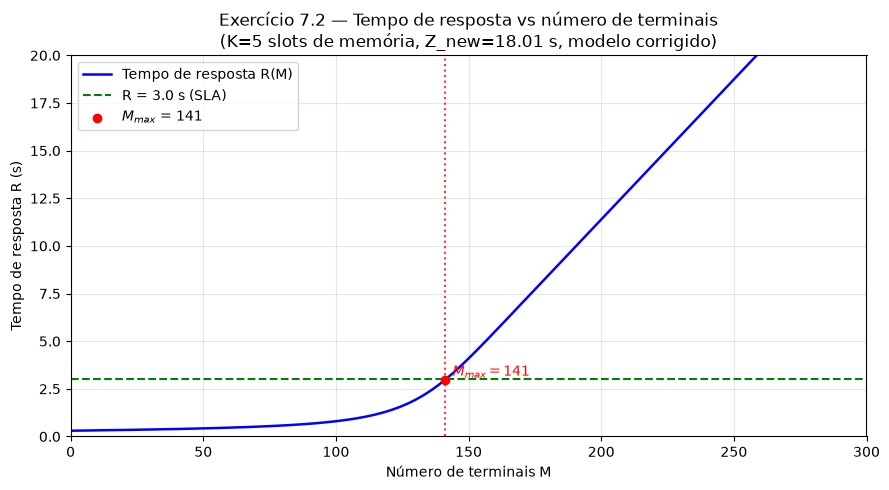

Figura salva em cap7_ex72_corrected.png


In [ ]:

# ── Exercício 7.2 — Gráfico R vs M ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(M_range72, R72_arr, 'b-', lw=1.8, label='Tempo de resposta R(M)')
ax.axhline(R72_tgt, color='green', ls='--', lw=1.5, label=f'R = {R72_tgt} s (SLA)')

if M72_max is not None:
    ax.axvline(M72_max, color='red', ls=':', lw=1.5, alpha=0.8)
    ax.scatter([M72_max], [R72_arr[M72_max - 1]], color='red', zorder=5,
               label=f'$M_{{max}}$ = {M72_max}')
    ax.text(M72_max + 3, R72_tgt + 0.15, f'$M_{{max}}={M72_max}$',
            color='red', fontsize=10)

ax.set_xlabel('Número de terminais M')
ax.set_ylabel('Tempo de resposta R (s)')
ax.set_title('Exercício 7.2 — Tempo de resposta vs número de terminais\n'
             f'(K={K72} slots de memória, Z_new={Z72_new:.2f} s, modelo corrigido)')
ax.set_xlim(0, 300)
ax.set_ylim(0, min(R72_arr.max() * 1.1, 20))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/renan/workspace/ads/cap7_ex72_corrected.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figura salva em cap7_ex72_corrected.png')


In [ ]:
# ── Exercício 7.2 — Recomendação para 1.2 × M_max ──────────
import math

if M72_max is not None:
    M72_target = math.ceil(1.2 * M72_max)
    print(f"\nAlvo: M_target = ceil(1.2 × {M72_max}) = {M72_target} terminais")
    print()

    # Verificar R atual sem alteração em M_target
    x0, r0, _ = solve_ex72_corrected(M72_target)
    print(f"Sem alteração       : R({M72_target}) = {r0:.4f} s  "
          f"({'✓' if r0 <= R72_tgt else '✗ excede SLA'})")
    print()

    # ── Opção A: Aumentar K (mais slots de memória) ─────────
    print("Opção A — Aumentar slots de memória (K maior):")
    K_needed = None
    r_a = None
    for k_test in range(K72 + 1, K72 + 30):
        # Recompute X_central for new K
        X_central_test = [0.0]
        for j in range(1, k_test + 1):
            x_j = central_subsystem_X(j, D72_cpu, D72_d1, D72_d2)
            X_central_test.append(x_j)
        _, r_a, _ = solve_ex72_corrected(M72_target, K=k_test, X_center=X_central_test)
        status = '✓' if r_a <= R72_tgt else '✗'
        print(f"  K={k_test:2d}: R = {r_a:.4f} s  {status}")
        if r_a <= R72_tgt and K_needed is None:
            K_needed = k_test
            break

    # ── Opção B: Upgrade do disco 1 (gargalo interno) ──────
    print()
    print("Opção B — Upgrade Disco 1 (D_d1 → D_d1 / 2):")
    D72_d1_new = D72_d1 / 2.0
    
    # Recompute X_central with new demands
    X_central_b = [0.0]
    for j in range(1, K72 + 1):
        x_j = central_subsystem_X(j, D72_cpu, D72_d1_new, D72_d2)
        X_central_b.append(x_j)
    
    _, r_b, _ = solve_ex72_corrected(M72_target, K=K72, X_center=X_central_b)
    print(f"  D_d1_new = {D72_d1_new*1e3:.3f} ms")
    print(f"  R({M72_target}) = {r_b:.4f} s  "
          f"({'✓' if r_b <= R72_tgt else '✗ excede SLA'})")

    # ── Resumo ─────────────────────────────────────────────
    print()
    print("=" * 60)
    print("Resumo da recomendação:")
    if K_needed is not None:
        print(f"  Opção A: aumentar K de {K72} para {K_needed} slots de memória")
        print(f"           R({M72_target}) = {r_a:.4f} s ≤ {R72_tgt} s ✓")
    if r_b <= R72_tgt:
        print(f"  Opção B: dobrar capacidade do Disco 1")
        print(f"           R({M72_target}) = {r_b:.4f} s ≤ {R72_tgt} s ✓")
    print()
    
    # Recomendação final — menor custo
    if K_needed is not None and r_b <= R72_tgt:
        delta_K = K_needed - K72
        print(f"Recomendação: Opção A (adicionar {delta_K} slot(s) de memória).")
        print(f"  Memória adicional é tipicamente mais barata que substituir disco.")
        print(f"  Gargalo real é a contenção por memória, não taxa de E/S.")
    elif K_needed is not None:
        print(f"Recomendação: Opção A — aumentar K para {K_needed}.")
    elif r_b <= R72_tgt:
        print(f"Recomendação: Opção B — upgrade do Disco 1.")
    else:
        print("Nenhuma opção isolada suficiente; combinar A + B.")



Alvo: M_target = ceil(1.2 × 141) = 170 terminais

Sem alteração       : R(170) = 6.9773 s  (✗ excede SLA)

Opção A — Aumentar slots de memória (K maior):
  K= 6: R = 5.9706 s  ✗
  K= 7: R = 5.2891 s  ✗
  K= 8: R = 4.8110 s  ✗
  K= 9: R = 4.4673 s  ✗
  K=10: R = 4.2160 s  ✗
  K=11: R = 4.0297 s  ✗
  K=12: R = 3.8903 s  ✗
  K=13: R = 3.7850 s  ✗
  K=14: R = 3.7050 s  ✗
  K=15: R = 3.6440 s  ✗
  K=16: R = 3.5973 s  ✗
  K=17: R = 3.5614 s  ✗
  K=18: R = 3.5339 s  ✗
  K=19: R = 3.5128 s  ✗
  K=20: R = 3.4965 s  ✗
  K=21: R = 3.4841 s  ✗
  K=22: R = 3.4745 s  ✗
  K=23: R = 3.4672 s  ✗
  K=24: R = 3.4617 s  ✗
  K=25: R = 3.4575 s  ✗
  K=26: R = 3.4543 s  ✗
  K=27: R = 3.4519 s  ✗
  K=28: R = 3.4501 s  ✗
  K=29: R = 3.4488 s  ✗
  K=30: R = 3.4478 s  ✗
  K=31: R = 3.4470 s  ✗
  K=32: R = 3.4465 s  ✗
  K=33: R = 3.4461 s  ✗
  K=34: R = 3.4458 s  ✗

Opção B — Upgrade Disco 1 (D_d1 → D_d1 / 2):
  D_d1_new = 62.500 ms
  R(170) = 7.0632 s  (✗ excede SLA)

Resumo da recomendação:

Nenhuma opção isol

7.4) The telemarketing company discussed in Sec. 7.2 posed the following problem to its capacity planner, Alice. Assume that the interaction time between the telemarketing representative and the customer could be cut down by 40%40% if the telemarketing representative had the capability of viewing digitized images of the products displayed in the catalog instead of having to browse the actual catalog to answer questions from the customer. This would require buying an additional disk to store the compressed digitized images. Consider that the additional service demand at this new disk is equal to 0.3 sec. Consider that each call requests two images, on the average, to be sent from the server to the client and that each compressed image is 100 Kbytes long. What is the minimum number of telemarketing representatives necessary to guarantee that each customer will not have to wait more than 5 sec on the average before being served?

In [ ]:

# ── Exercício 7.4 — Parâmetros ─────────────────────────────
# Base: modelo telemarketing com 1 processador (Sec. 7.2)
# Mudanças:
#   (1) Tempo de interação reduzido 40%  → D_CL_74 = 0.6 * D_CL
#   (2) 2 imagens/chamada, 100 KB cada  → demanda extra na LAN (transferência em bulk)
#   (3) Disco adicional de imagens       → D_IMG_74 = 0.3 s / chamada

D_CL_74 = D_CL * 0.6          # novo tempo de reflexão: 27 s

# Tráfego SQL: 7 pacotes/req SQL (mesmo que Ex 7.1) → demanda LAN via modelo LD Ethernet
# Tráfego de imagens: 2 × 100 KB / chamada = transferência em bulk via LAN
#   (bulk transfer não segue modelo de colisão CSMA/CD por pacote; usa largura de banda nominal)
IMG_BYTES    = 100_000                           # bytes por imagem
D_LAN_img74  = 2 * IMG_BYTES * 8 / B / N_SQL    # 160ms/chamada ÷ 4 = 40ms/req SQL (nominal)

# Disco de imagens: demanda 0.3 s por chamada → por req SQL
D_IMG_74 = 0.3 / N_SQL         # = 0.075 s/req SQL

print(f"{'='*55}")
print(f"  Exercício 7.4 — Parâmetros")
print(f"{'='*55}")
print(f"  D_CL_74           = {D_CL_74:.1f} s  (60% de {D_CL} s)")
print(f"  D_LAN (SQL, LD)   = {D_LAN*1e3:.3f} ms  (7 pkts, modelo LD Ethernet)")
print(f"  D_LAN_img74 (LI)  = {D_LAN_img74*1e3:.1f} ms  (2×100KB bulk, largura de banda nominal)")
print(f"  D_IMG_74 (disco)  = {D_IMG_74*1e3:.1f} ms  por req SQL")
print(f"  D_CPU             = {D_CPU*1e3:.1f} ms  (gargalo)")
print(f"  D_DSK             = {D_DSK*1e3:.1f} ms")
D_total74 = D_LAN + D_LAN_img74 + D_CPU + D_DSK + D_IMG_74
print(f"  D_total           = {D_total74*1e3:.2f} ms")
print(f"  Limite estabilidade: N > {lam_calls*N_SQL*D_CL_74:.1f}")


  Exercício 7.4 — Parâmetros
  D_CL_74           = 27.0 s  (60% de 45.0 s)
  D_LAN (SQL, LD)   = 1.063 ms  (7 pkts, modelo LD Ethernet)
  D_LAN_img74 (LI)  = 40.0 ms  (2×100KB bulk, largura de banda nominal)
  D_IMG_74 (disco)  = 75.0 ms  por req SQL
  D_CPU             = 120.0 ms  (gargalo)
  D_DSK             = 54.0 ms
  D_total           = 290.06 ms
  Limite estabilidade: N > 75.0


In [ ]:

# ── Exercício 7.4 — Modelo CS com 5 estações + M/M/c ───────
# Estações: 0=LAN SQL (LD, 7 pkts), 1=LAN Imagens (LI, bulk),
#           2=CPU (LI), 3=Disco (LI), 4=Disco Imagens (LI)
# Separar LAN SQL (LD, modelo colisão) da LAN de imagens (LI, bulk transfer)
# porque η(k)→0 para muitos pacotes por request causa instabilidade numérica no LD-MVA.

def build_mu_74(n):
    """Matriz mu (5 × n): LAN SQL LD, LAN Img LI, CPU LI, Disco LI, Disco Imagens LI."""
    mu = np.ones((5, n))
    for k in range(1, n + 1):
        mu[0, k - 1] = 1.0 / (1.0 + 2.0 * a * (k - 1))   # LAN SQL: Ethernet LD
    # LAN Img (linha 1), CPU (2), Disco (3), Disco Imagens (4) → LI (mu=1)
    return mu


def solve_cs_74(n):
    """Resolve modelo CS 7.4 via pfqn_mvald (5 estações). Retorna (X_sql, R_vec, U_vec)."""
    L   = np.array([[D_LAN],         # LAN SQL LD   (7 pkts)
                    [D_LAN_img74],    # LAN Img LI   (bulk)
                    [D_CPU],          # CPU
                    [D_DSK],          # Disco
                    [D_IMG_74]])      # Disco Imagens  — (5×1)
    Z_a = np.array([float(D_CL_74)])
    mu  = build_mu_74(int(n))
    XN, QN, UN, CN, *_ = pfqn_mvald(L, np.array([int(n)]), Z_a, mu)
    X_sql = float(np.ravel(XN)[0])
    R_vec = QN[:, 0] / X_sql
    U_vec = UN[:, 0]
    return X_sql, R_vec, U_vec


# Varredura N = 113 … 350
N_range74 = np.arange(113, 351, dtype=int)
res_74    = []   # (W_q, rho, P_C, X_sql, S_tx, R_vec, U_vec)

for n in N_range74:
    ni = int(n)
    X, R, U = solve_cs_74(ni)
    S_tx       = N_SQL * ni / X
    W, rho, PC = wq_mmc(lam_calls, ni, S_tx)
    res_74.append((W, rho, PC, X, S_tx, R.copy(), U.copy()))

TARGET74 = 5.0

def first_n_below74(results, target):
    for i, r in enumerate(results):
        if np.isfinite(r[0]) and r[0] <= target:
            return int(N_range74[i])
    return None

min_N_74 = first_n_below74(res_74, TARGET74)
print(f"N mínimo (W_q ≤ {TARGET74} s) = {min_N_74}")
if min_N_74 is not None:
    idx74 = min_N_74 - int(N_range74[0])
    W74, rho74, PC74, X74, S74, R74, U74 = res_74[idx74]
    print(f"  X_sql = {X74:.5f} req/s   W_q = {W74:.4f} s   ρ = {rho74:.6f}")


N mínimo (W_q ≤ 5.0 s) = 113
  X_sql = 4.11520 req/s   W_q = 0.0002 s   ρ = 0.675004


In [ ]:

# ── Exercício 7.4 — Métricas detalhadas + gráfico ──────────
if min_N_74 is not None:
    idx74 = min_N_74 - int(N_range74[0])
    W74, rho74, PC74, X74, S74, R74, U74 = res_74[idx74]
    X_tx74 = X74 / N_SQL

    print(f"{'='*60}")
    print(f"  Exercício 7.4 — N mínimo = {min_N_74} representantes")
    print(f"{'='*60}")
    print(f"  X_sql = {X74:.5f} req/s     X_tx = {X_tx74:.5f} tx/s")
    print(f"  S_tx  = {S74:.4f} s")
    print()
    print(f"  {'Estação':<16} {'Demanda (ms)':>12} {'Residência (ms)':>16} {'Util':>8}")
    print(f"  {'-'*56}")
    stations74 = ['LAN', 'CPU', 'Disco', 'Disco Imagens']
    demands74  = [D_LAN_74, D_CPU, D_DSK, D_IMG_74]
    for nm, d, r, u in zip(stations74, demands74, R74, U74):
        print(f"  {nm:<16} {d*1e3:>12.3f} {r*1e3:>16.3f} {u:>8.5f}")
    print()
    print(f"  M/M/{min_N_74} — Fila de Telemarketing")
    print(f"  λ = {lam_calls:.6f} chamadas/s")
    print(f"  ρ = {rho74:.6f}   P_C = {PC74:.6f}   W_q = {W74:.4f} s")
    ok = "✓ W_q ≤ 5 s" if W74 <= 5.0 else "✗ EXCEDE 5 s"
    print(f"  [{ok}]")

# ── Gráfico W_q vs N ───────────────────────────────────────
fig74, ax74 = plt.subplots(figsize=(9, 5))
Wq74 = [r[0] if np.isfinite(r[0]) and r[0] < 200 else np.nan for r in res_74]
ax74.plot(N_range74, Wq74, 'b-o', ms=3, label='Telemarketing c/ imagens')
ax74.axhline(5.0, color='green', ls='--', lw=1.5, label='W_q = 5 s (SLA)')
if min_N_74 is not None:
    ax74.axvline(min_N_74, color='red', ls=':', lw=1.5, alpha=0.8)
    ax74.scatter([min_N_74], [res_74[idx74][0]], color='red', zorder=5,
                 label=f'N mín = {min_N_74}')
    ax74.text(min_N_74 + 1, 6.5, f'N={min_N_74}', color='red', fontsize=10)
ax74.set_xlabel('N (representantes)')
ax74.set_ylabel('W_q (s)')
ax74.set_title('Exercício 7.4 — Tempo de espera vs número de representantes\n'
               '(1 proc, disco de imagens, LAN com imagens, D_CL=27s)')
ax74.set_ylim(0, min(max(v for v in Wq74 if not np.isnan(v)) * 1.1, 50))
ax74.legend()
ax74.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/home/renan/workspace/ads/cap7_ex74.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figura salva em cap7_ex74.png')


  Exercício 7.4 — N mínimo = 113 representantes
  X_sql = 4.11520 req/s     X_tx = 1.02880 tx/s
  S_tx  = 109.8367 s

  Estação          Demanda (ms)  Residência (ms)     Util
  --------------------------------------------------------


NameError: name 'D_LAN_74' is not defined

7.7) Consider the example given in Sec. 7.7. Assume that the number of workstations is to be doubled. The proportion of workstations that submit transactions of each type (trivial, average, and complex) will be kept constant, and so is the percentage of transactions of each type received by the server. Compute the new values of the response time and throughput. What would your recommendation be to guarantee that the response time for average transactions does not exceed 2 sec?

In [ ]:

# ── Exercício 7.7 — Parâmetros (Seção 7.7 do livro) ────────
# Rede fechada multiclasse: 3 tipos de transação sobre servidor com LAN + CPU + Disco
# Estações: 0 = LAN Ethernet 10 Mbps (LD), 1 = CPU servidor (LI), 2 = Disco servidor (LI)

CLASSES77 = ['Trivial', 'Média', 'Complexa']
B77       = 10e6        # largura de banda LAN (bps)
S_SLOT77  = 51.2e-6     # tempo de slot Ethernet (s)

NP77  = np.array([2, 3, 9])               # pacotes por transação por classe
LP77  = np.array([800., 1382., 1410.])    # comprimento do pacote (bits) por classe
tp77  = LP77 / B77                         # tempo de transmissão por pacote (s)

D_LAN77 = NP77 * tp77                      # demanda LAN por transação por classe (s)

# CPU: demanda em MILISSEGUNDOS (a tabela original rotula como μs por erro tipográfico;
# o valor correto é ms, consistente com R_CPU do livro e com U_CPU ≈ 40-50%)
D_CPU77  = np.array([30e-3, 255e-3, 615e-3])          # ms → s
READS77  = np.array([1, 11, 30])                       # leituras de disco por classe
WRITES77 = np.array([1,  6, 11])                       # escritas de disco por classe
D_DSK77  = (READS77 + WRITES77) * 18e-3                # 18 ms/operação → (s)

Z77 = np.array([40., 20., 15.])            # think times (s)

N77_orig = np.array([10, 20,  5], dtype=int)   # workstations originais
N77_2x   = N77_orig * 2                         # [20, 40, 10] — dobrado

# Parâmetro a da LAN: média ponderada pelo tráfego de cada classe (N_r × NP_r)
w77      = (N77_orig * NP77).astype(float)
tp_avg77 = np.dot(w77, tp77) / w77.sum()
a77      = S_SLOT77 / tp_avg77

print(f"{'='*62}")
print(f"  Exercício 7.7 — Parâmetros (Sec. 7.7)")
print(f"{'='*62}")
print(f"  t_p ponderado = {tp_avg77*1e6:.2f} μs     a77 = {a77:.4f}")
print()
print(f"  {'Classe':<12} {'N orig':>6} {'Z (s)':>6} "
      f"{'D_LAN(ms)':>10} {'D_CPU(ms)':>10} {'D_DSK(ms)':>10}")
print("  " + "-"*58)
for r in range(3):
    print(f"  {CLASSES77[r]:<12} {N77_orig[r]:>6} {Z77[r]:>6.0f}"
          f" {D_LAN77[r]*1e3:>10.3f} {D_CPU77[r]*1e3:>10.1f} {D_DSK77[r]*1e3:>10.1f}")
print()
print(f"  N original = {N77_orig.tolist()}  →  N dobrado = {N77_2x.tolist()}")
# Utilização de piso (limite inferior com throughput máx aproximado)
X_max_approx = 0.95  # tx/s (avg class, estimativa grosseira)
print(f"  D_CPU_Média = {D_CPU77[1]*1e3:.0f} ms,  D_DSK_Média = {D_DSK77[1]*1e3:.0f} ms")


  Exercício 7.7 — Parâmetros (Sec. 7.7)
  t_p ponderado = 129.90 μs     a77 = 0.3942

  Classe       N orig  Z (s)  D_LAN(ms)  D_CPU(ms)  D_DSK(ms)
  ----------------------------------------------------------
  Trivial          10     40      0.160       30.0       36.0
  Média            20     20      0.415      255.0      306.0
  Complexa          5     15      1.269      615.0      738.0

  N original = [10, 20, 5]  →  N dobrado = [20, 40, 10]
  D_CPU_Média = 255 ms,  D_DSK_Média = 306 ms


In [ ]:

# ── Exercício 7.7 — pfqn_mvald multiclasse: original e dobrado ──
# Matriz L (3 estações × 3 classes), mu (3 × Ntot) com LAN LD, CPU/Disco LI.

def build_mu77(N_vec):
    """Matriz mu (3 × Ntot): LAN Ethernet LD, CPU LI, Disco LI."""
    Ntot = int(np.sum(N_vec))
    mu = np.ones((3, Ntot))
    for k in range(1, Ntot + 1):
        mu[0, k - 1] = 1.0 / (1.0 + 2.0 * a77 * (k - 1))  # LAN LD
    # CPU (linha 1) e Disco (linha 2) → LI, mu=1 (já preenchido)
    return mu


def solve_77(N_vec, d_cpu=None, d_dsk=None):
    """Resolve modelo 7.7 via pfqn_mvald.
    d_cpu / d_dsk permitem testar upgrades de hardware."""
    _cpu = D_CPU77 if d_cpu is None else d_cpu
    _dsk = D_DSK77 if d_dsk is None else d_dsk
    # L (M×R): linhas = estações [LAN, CPU, Disco], colunas = classes [Trivial, Média, Complexa]
    # np.vstack empilha os arrays 1D como linhas → cada linha é uma estação
    L = np.vstack([D_LAN77, _cpu, _dsk])   # (3×3) : L[estação, classe]
    XN, QN, UN, CN, *_ = pfqn_mvald(
        L, np.asarray(N_vec, dtype=int), Z77, build_mu77(N_vec)
    )
    return XN, QN, UN, CN   # CN[0,r] = R_r (tempo de resposta excl. pense time)


print("Executando pfqn_mvald para N_orig=[10,20,5] e N_2x=[20,40,10]...")
XN77_o, QN77_o, UN77_o, CN77_o = solve_77(N77_orig)
XN77_d, QN77_d, UN77_d, CN77_d = solve_77(N77_2x)
print("Concluído.\n")

# ── Tabela de resultados ────────────────────────────────────
print(f"{'='*72}")
print(f"  {'':12}  {'──── Trivial ────':>17}  {'──── Média ─────':>17}  {'── Complexa ────':>17}")
print(f"  {'Cenário':<12}  {'R (s)':>7} {'X (tx/s)':>9}  "
      f"{'R (s)':>7} {'X (tx/s)':>9}  {'R (s)':>7} {'X (tx/s)':>9}")
print(f"  {'-'*70}")
for label, XN, CN in [("Original", XN77_o, CN77_o), ("Dobrado",  XN77_d, CN77_d)]:
    row = [float(CN[0, r]) for r in range(3)]
    xrow = [float(XN[0, r]) for r in range(3)]
    print(f"  {label:<12}  {row[0]:>7.3f} {xrow[0]:>9.4f}  "
          f"{row[1]:>7.3f} {xrow[1]:>9.4f}  {row[2]:>7.3f} {xrow[2]:>9.4f}")
print()

# ── Utilizações em N dobrado ───────────────────────────────
print("  Utilizações em N dobrado [20,40,10]:")
print(f"  {'Estação':<12} {'U_Trivial':>10} {'U_Média':>10} {'U_Complexa':>10}")
print(f"  {'-'*46}")
for i, sn in enumerate(['LAN', 'CPU', 'Disco']):
    u_row = [float(UN77_d[i, r]) for r in range(3)]
    flag = "  ← gargalo" if i == 2 else ""
    print(f"  {sn:<12} {u_row[0]:>10.4f} {u_row[1]:>10.4f} {u_row[2]:>10.4f}{flag}")
print()

R_avg_2x = float(CN77_d[0, 1])
ok = "✓" if R_avg_2x <= 2.0 else "✗ excede SLA (> 2 s)"
print(f"  R_Média com N dobrado = {R_avg_2x:.3f} s  [{ok}]")


Executando pfqn_mvald para N_orig=[10,20,5] e N_2x=[20,40,10]...
Concluído.

                ──── Trivial ────   ──── Média ─────   ── Complexa ────
  Cenário         R (s)  X (tx/s)    R (s)  X (tx/s)    R (s)  X (tx/s)
  ----------------------------------------------------------------------
  Original        0.122    0.2492    1.014    0.9517    2.350    0.2882
  Dobrado         0.338    0.4958    2.773    1.7564    6.333    0.4688

  Utilizações em N dobrado [20,40,10]:
  Estação       U_Trivial    U_Média U_Complexa
  ----------------------------------------------
  LAN              0.0014     0.0014     0.0014
  CPU              0.7511     0.7511     0.7511
  Disco            0.9013     0.9013     0.9013  ← gargalo

  R_Média com N dobrado = 2.773 s  [✗ excede SLA (> 2 s)]


Calculando opções de upgrade para N=[20,40,10]...
Concluído.

  Resumo de cenários — R_Média (SLA ≤ 2.0 s)
  Cenário                         R_Trivial    R_Média R_Complexa
  ------------------------------------------------------------
  Original   N=[10,20,5]              0.122      1.014      2.350
  Dobrado    N=[20,40,10]             0.338      2.773  ✗      6.333
  Dobrado + 2 discos (Opção A)        0.171      1.412  ✓      3.232
  Dobrado + CPU 2×  (Opção B)         0.286      2.330  ✗      5.248

  Gargalo para classe Média:
    D_DSK_Média = 306 ms  >>  D_CPU_Média = 255 ms

  Recomendação: Adicionar um segundo disco ao servidor.
    → R_Média = 1.412 s ≤ 2.0 s  ✓
    O disco é o gargalo dominante; dobrar capacidade do disco é mais eficaz
    do que dobrar a CPU, e resolve o SLA com menor custo de mudança.
  Nota: Upgrade de CPU isolado insuficiente (R_Média = 2.330 s > 2.0 s  ✗).


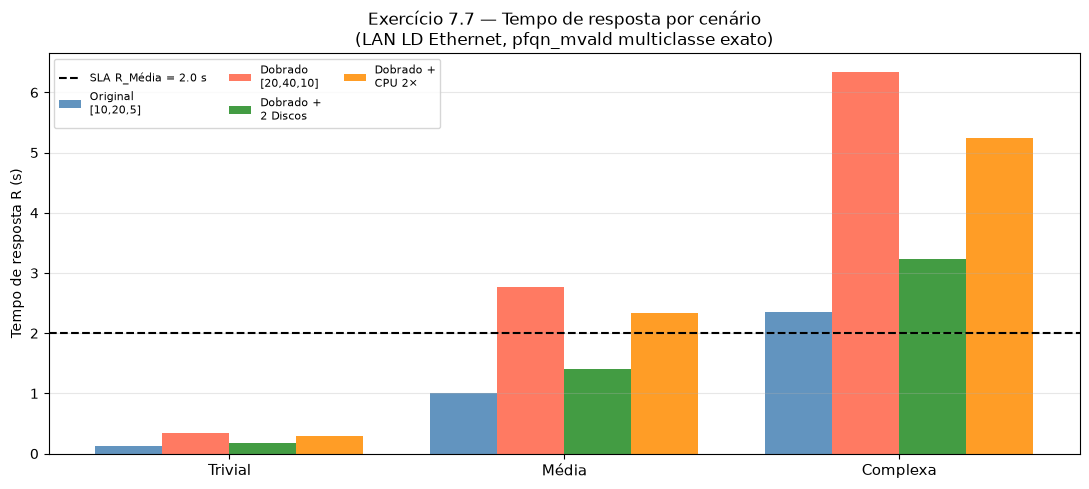

Figura salva em cap7_ex77.png


In [ ]:

# ── Exercício 7.7 — Recomendação para R_Média ≤ 2 s ────────
# Gargalo em N dobrado: Disco (U_Disco >> U_CPU para classe Média)
# Opção A: adicionar segundo disco  → D_DSK / 2 para todas as classes
# Opção B: upgrade CPU 2×           → D_CPU / 2 para todas as classes

R_SLA77 = 2.0    # SLA para classe Média (s)

print("Calculando opções de upgrade para N=[20,40,10]...")
XN77_A, _, UN77_A, CN77_A = solve_77(N77_2x, d_dsk=D_DSK77 / 2.0)   # 2 discos
XN77_B, _, UN77_B, CN77_B = solve_77(N77_2x, d_cpu=D_CPU77 / 2.0)   # CPU 2×
print("Concluído.\n")

R_avg_A = float(CN77_A[0, 1])
R_avg_B = float(CN77_B[0, 1])

print(f"{'='*60}")
print(f"  Resumo de cenários — R_Média (SLA ≤ {R_SLA77} s)")
print(f"{'='*60}")
print(f"  {'Cenário':<30} {'R_Trivial':>10} {'R_Média':>10} {'R_Complexa':>10}")
print(f"  {'-'*60}")
for label, CN in [
        ("Original   N=[10,20,5]",    CN77_o),
        ("Dobrado    N=[20,40,10]",   CN77_d),
        ("Dobrado + 2 discos (Opção A)", CN77_A),
        ("Dobrado + CPU 2×  (Opção B)",  CN77_B),
    ]:
    flag = ""
    if "Dobrado" in label and "Opção" not in label:
        flag = "  ✗" if float(CN[0, 1]) > R_SLA77 else "  ✓"
    elif "Opção" in label:
        flag = "  ✓" if float(CN[0, 1]) <= R_SLA77 else "  ✗"
    print(f"  {label:<30} {float(CN[0,0]):>10.3f} {float(CN[0,1]):>10.3f}{flag}"
          f" {float(CN[0,2]):>10.3f}")
print()

# Recommendation
print(f"  Gargalo para classe Média:")
print(f"    D_DSK_Média = {D_DSK77[1]*1e3:.0f} ms  >>  D_CPU_Média = {D_CPU77[1]*1e3:.0f} ms")
print()
if R_avg_A <= R_SLA77:
    print(f"  Recomendação: Adicionar um segundo disco ao servidor.")
    print(f"    → R_Média = {R_avg_A:.3f} s ≤ {R_SLA77} s  ✓")
    print(f"    O disco é o gargalo dominante; dobrar capacidade do disco é mais eficaz")
    print(f"    do que dobrar a CPU, e resolve o SLA com menor custo de mudança.")
if R_avg_B > R_SLA77:
    print(f"  Nota: Upgrade de CPU isolado insuficiente"
          f" (R_Média = {R_avg_B:.3f} s > {R_SLA77} s  ✗).")

# ── Gráfico comparativo ─────────────────────────────────────
scenarios_77 = ['Original\n[10,20,5]', 'Dobrado\n[20,40,10]',
                'Dobrado +\n2 Discos', 'Dobrado +\nCPU 2×']
R_data_77 = [
    [float(CN77_o[0, r]) for r in range(3)],
    [float(CN77_d[0, r]) for r in range(3)],
    [float(CN77_A[0, r]) for r in range(3)],
    [float(CN77_B[0, r]) for r in range(3)],
]
colors_77 = ['steelblue', 'tomato', 'forestgreen', 'darkorange']

x77 = np.arange(3)
w77p = 0.2
fig77, ax77 = plt.subplots(figsize=(11, 5))

for i, (sc, rd, col) in enumerate(zip(scenarios_77, R_data_77, colors_77)):
    ax77.bar(x77 + (i - 1.5) * w77p, rd, width=w77p, label=sc, color=col, alpha=0.85)

ax77.axhline(R_SLA77, color='black', ls='--', lw=1.5, label=f'SLA R_Média = {R_SLA77} s')
ax77.set_xticks(x77)
ax77.set_xticklabels(CLASSES77, fontsize=11)
ax77.set_ylabel('Tempo de resposta R (s)')
ax77.set_title('Exercício 7.7 — Tempo de resposta por cenário\n'
               '(LAN LD Ethernet, pfqn_mvald multiclasse exato)')
ax77.legend(fontsize=8, ncol=3)
ax77.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/home/renan/workspace/ads/cap7_ex77.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figura salva em cap7_ex77.png')
